<a href="https://colab.research.google.com/github/sureshs59/sureshsunuguri/blob/main/DecisiontreeAlgorithm_Weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Decision Tree Algorithm: Key Concepts

A**Decision Tree** is a supervised machine learning algorithm that can be used for both classification and regression tasks. It builds a model in the form of a tree structure, where each internal node represents a "test" on an attribute (e.g., is the temperature > 20°C?), each branch represents the outcome of the test, and each leaf node represents a class label (for classification) or a numerical value (for regression).

**Key Concepts:**

1.  **Nodes:**
    *   **Root Node:** The topmost node in the tree. It represents the entire dataset, which then gets split into two or more homogeneous sets.
    *   **Internal Node (Decision Node):** A node that splits the data into further sub-nodes based on a certain condition or attribute test.
    *   **Leaf Node (Terminal Node):** A node that does not split the data any further. It represents the final decision or prediction (class label or value).

2.  **Branches:** These are the connections between nodes, representing the possible outcomes of a decision or test.

3.  **Splitting:** The process of dividing a node into two or more sub-nodes. The goal is to create sub-nodes that are as "pure" as possible (i.e., contain data points mostly belonging to a single class).

4.  **Decision Rules:** The paths from the root to a leaf node represent a set of rules that lead to a particular decision.

5.  **Impurity Measures:** Decision trees use measures to determine the "best" way to split a node. The goal is to minimize impurity after a split.
    *   **Gini Impurity:** Measures how often a randomly chosen element from the set would be incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset. A Gini impurity of 0 means all elements belong to a single class.
    *   **Entropy:** A measure of disorder or uncertainty. In the context of decision trees, it measures the randomness of the class labels in a node. A lower entropy indicates higher purity.

6.  **Information Gain:** This is the decrease in entropy (or Gini impurity) after a dataset is split on an attribute. The attribute with the highest information gain is usually chosen for the split.

7.  **Pruning:** The process of removing branches from the tree that may be learning too much from the training data (i.e., overfitting). Pruning helps improve the model's generalization to unseen data.

### Simple Example: Deciding Whether to Play Tennis

Let's say we want to decide if we should play tennis based on the weather conditions. Here's a very simple dataset:

| Outlook    | Temperature | Humidity | Wind   | Play Tennis |
| :--------- | :---------- | :------- | :----- | :---------- |
| Sunny      | Hot         | High     | Weak   | No          |
| Sunny      | Hot         | High     | Strong | No          |
| Overcast   | Hot         | High     | Weak   | Yes         |
| Rain       | Mild        | High     | Weak   | Yes         |
| Rain       | Cool        | Normal   | Weak   | Yes         |
| Rain       | Cool        | Normal   | Strong | No          |
| Overcast   | Cool        | Normal   | Strong | Yes         |
| Sunny      | Mild        | High     | Weak   | No          |
| Sunny      | Cool        | Normal   | Weak   | Yes         |
| Rain       | Mild        | Normal   | Weak   | Yes         |
| Sunny      | Mild        | Normal   | Strong | Yes         |
| Overcast   | Mild        | High     | Strong | Yes         |
| Overcast   | Hot         | Normal   | Weak   | Yes         |
| Rain       | Mild        | High     | Strong | No          |

**Building the Decision Tree (Simplified):**

1.  **Root Node:** Start with the entire dataset (14 instances).

2.  **First Split:** The algorithm would evaluate which attribute (Outlook, Temperature, Humidity, or Wind) provides the most information gain (i.e., creates the purest child nodes).
    Let's assume 'Outlook' provides the best split:
    *   **Outlook = Sunny:** Leads to 3 'No' and 2 'Yes' (Impure)
    *   **Outlook = Overcast:** Leads to 4 'Yes' (Pure! This becomes a leaf node: Play Tennis = Yes)
    *   **Outlook = Rain:** Leads to 3 'Yes' and 2 'No' (Impure)

3.  **Second Split (for 'Sunny' branch):** Since the 'Sunny' branch is impure, we split it further. Let's say 'Humidity' is the next best attribute.
    *   **If Outlook = Sunny and Humidity = High:** Leads to 3 'No' (Pure! Leaf node: Play Tennis = No)
    *   **If Outlook = Sunny and Humidity = Normal:** Leads to 2 'Yes' (Pure! Leaf node: Play Tennis = Yes)

4.  **Second Split (for 'Rain' branch):** Similarly, for the 'Rain' branch, let's say 'Wind' is the best attribute.
    *   **If Outlook = Rain and Wind = Weak:** Leads to 3 'Yes' (Pure! Leaf node: Play Tennis = Yes)
    *   **If Outlook = Rain and Wind = Strong:** Leads to 2 'No' (Pure! Leaf node: Play Tennis = No)

**The resulting Decision Tree would look something like this:**

```
Outlook?
├── Sunny
│   └── Humidity?
│       ├── High
│       │   └── Play Tennis = No
│       └── Normal
│           └── Play Tennis = Yes
├── Overcast
│   └── Play Tennis = Yes
└── Rain
    └── Wind?
        ├── Weak
        │   └── Play Tennis = Yes
        └── Strong
            └── Play Tennis = No
```

**How to use it:** To decide whether to play tennis, you just follow the path from the root node down to a leaf node based on the current weather conditions. For example, if 'Outlook' is 'Sunny' and 'Humidity' is 'High', the tree tells you 'Play Tennis = No'.

This example demonstrates how a Decision Tree uses a series of simple questions (splits) to arrive at a final decision.

### 9. Decision Tree Coding Example with Weather Dataset

Let's implement a Decision Tree Classifier using a dataset similar to our 'Play Tennis' example. We'll simulate a dataset, preprocess it, train the model, make predictions, and evaluate its performance.

In [31]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1. Create the Weather Dataset (similar to Play Tennis example)
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df_weather = pd.DataFrame(data)

print("Original Weather Dataset:")
display(df_weather.head(15))


Original Weather Dataset:


,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


### 10. Preprocessing the Data

Decision Trees from scikit-learn typically work with numerical input. We need to convert our categorical features (Outlook, Temperature, Humidity, Wind, PlayTennis) into numerical representations. We'll use `LabelEncoder` for this.

In [38]:
# 2. Preprocessing: Convert categorical features to numerical
le = LabelEncoder()
for column in df_weather.columns:
    df_weather[column] = le.fit_transform(df_weather[column])

print("\nEncoded Weather Dataset:")
display(df_weather.head(15))

# Separate features (X) and target (y)
X_weather = df_weather.drop('PlayTennis', axis=1)
y_weather = df_weather['PlayTennis']

print("\nFeatures (X_weather) shape:", X_weather.shape)
print("Target (y_weather) shape:", y_weather.shape)



Encoded Weather Dataset:


,Outlook,Temperature,Humidity,Wind,PlayTennis
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1



Features (X_weather) shape: (14, 4)
Target (y_weather) shape: (14,)


### 11. Splitting the Data into Training and Testing Sets

We'll split the encoded dataset into training and testing sets to evaluate our model's performance on unseen data. A common split is 70% for training and 30% for testing.

In [39]:
# 3. Split data into training and testing sets
X_train_weather, X_test_weather, y_train_weather, y_test_weather = train_test_split(
    X_weather, y_weather, test_size=0.3, random_state=42, stratify=y_weather
)

print("\nTraining features shape:", X_train_weather.shape)
print("Testing features shape:", X_test_weather.shape)
print("Training target shape:", y_train_weather.shape)
print("Testing target shape:", y_test_weather.shape)



Training features shape: (9, 4)
Testing features shape: (5, 4)
Training target shape: (9,)
Testing target shape: (5,)


### 12. Training the Decision Tree Classifier

Now, we'll initialize and train a `DecisionTreeClassifier` from `sklearn.tree`. We'll use `random_state` for reproducibility.

In [40]:
# 4. Train the Decision Tree Classifier
dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X_train_weather, y_train_weather)

print("Decision Tree Model trained successfully!")


Decision Tree Model trained successfully!


### 13. Making Predictions and Evaluating the Model

Once trained, we'll use our model to make predictions on the test set and evaluate its performance using accuracy, a confusion matrix, and a classification report.

In [41]:
# 5. Make predictions on the test set
y_pred_weather = dtree_model.predict(X_test_weather)

# 6. Evaluate the model
accuracy_weather = accuracy_score(y_test_weather, y_pred_weather)
conf_matrix_weather = confusion_matrix(y_test_weather, y_pred_weather)
class_report_weather = classification_report(y_test_weather, y_pred_weather)

print(f"\nDecision Tree Accuracy: {accuracy_weather:.2f}")
print("\nDecision Tree Confusion Matrix:\n", conf_matrix_weather)
print("\nDecision Tree Classification Report:\n", class_report_weather)



Decision Tree Accuracy: 0.40

Decision Tree Confusion Matrix:
 [[0 2]
 [1 2]]

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      0.67      0.57         3

    accuracy                           0.40         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.30      0.40      0.34         5



### 14. Visualizing the Decision Tree

One of the great advantages of Decision Trees is their interpretability. We can visualize the entire tree structure to understand how decisions are made.

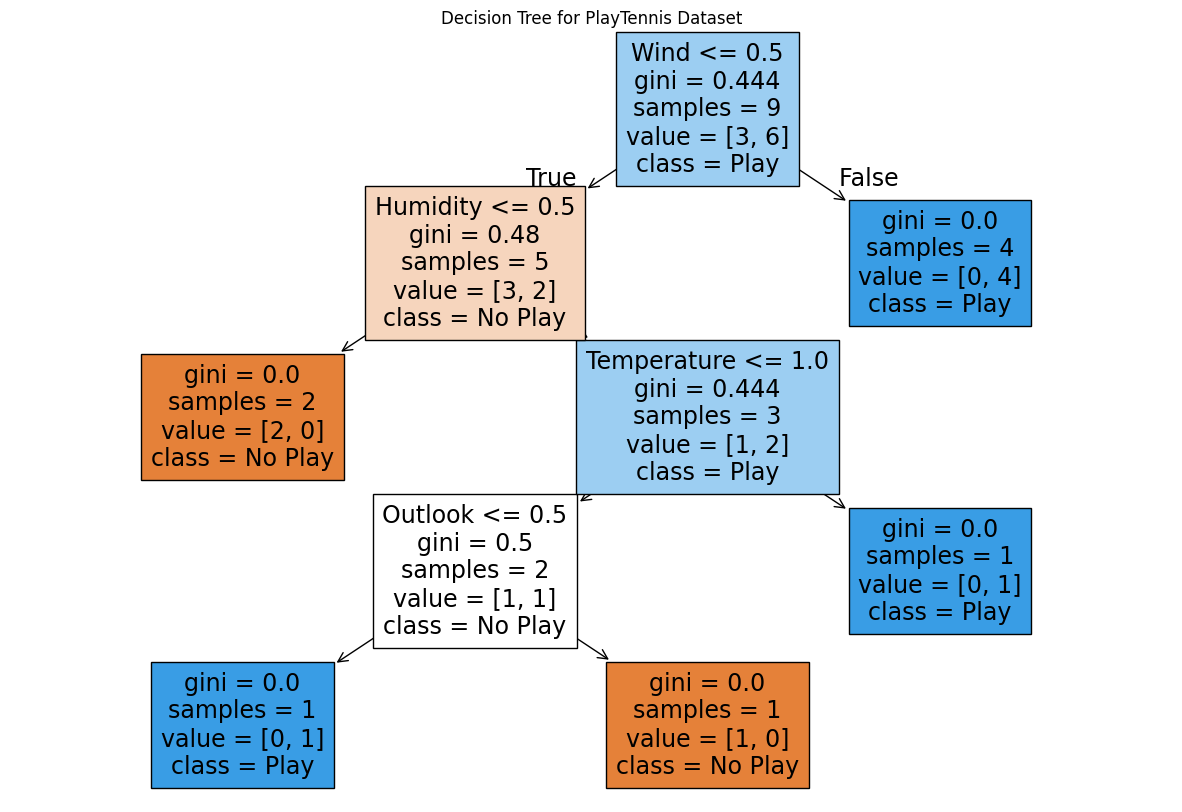

In [42]:
# 7. Visualize the Decision Tree
plt.figure(figsize=(15, 10))
plot_tree(dtree_model, filled=True, feature_names=X_weather.columns, class_names=['No Play', 'Play'])
plt.title('Decision Tree for PlayTennis Dataset')
plt.show()
